# SMACNP Predictions — Combined ERA5 + PeakWeather Context

Loads trained SMACNP models and evaluates predictions on holdout PeakWeather
test stations.

## What this notebook does

For each cross-validation fold:
1. Loads the trained model checkpoint for that fold.
2. Identifies the holdout time period (a contiguous fifth of the common date range).
3. Builds the **combined context** for every holdout day:
   - ERA5 reanalysis grid (~1769 cells, source flag = 0)
   - PeakWeather train stations (~137 stations, source flag = 1)
4. Predicts temperature (mean μ and uncertainty σ) at the **35 held-out PeakWeather
   test stations** — stations never used as context during training.
5. Compares against a regression kriging baseline (Universal Kriging with linear drift).

After all folds, the non-overlapping holdout periods are concatenated to give a
full-year evaluation:
- Per-station error maps (MAE, RMSE, Bias)
- CRPS and skill score vs regression kriging baseline
- Uncertainty calibration (Q-Q plot, reliability diagram)
- Error correlations with altitude, mTPI, and day of year

## Ground truth

Predictions are evaluated against raw **PeakWeather observations** at the test
stations. All temperatures are in °C after denormalisation
using the ERA5 statistics saved in `metadata.json`.


In [1]:
%pip install -qq -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
MODEL_NAME = 'test-combined-era5-pw-mean-13'
PW_FIRST_DATE = '2017-01-01'
PW_LAST_DATE = '2024-12-31'
PW_VALIDITY_THRESHOLD = 0.99
STATION_SPLIT_SEED = 42   # must match training notebook exactly


In [3]:
from pathlib import Path

import params

params.configure_renku_cuda()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import datasets as ds
import inference as inf
import metrics
import model_factory
import visualization as vis
from convCNP.training.training_elev import get_fold_holdout_indices, select_holdout_day

In [4]:
device = params.select_device()
print(f'Using device: {device}')

Using device: cuda


## Configuration

Specify the trained model directory to load.

In [5]:
# Path to trained model directory
MODEL_DIR = Path('./trained_models') / MODEL_NAME

# Default data paths (used as fallback for older checkpoints without saved paths)
DEFAULT_ERA5_MAX_TEMP_GLOB = './datasets/ERA5_Land/max_temperature/*.nc'
DEFAULT_ERA5_MEAN_TEMP_GLOB = './datasets/ERA5_Land/temperature/*.nc'
DEFAULT_ERA5_GEOPOTENTIAL_GLOB = './datasets/ERA5_Land/geopotential/*.nc'
DEFAULT_METEO_SWISS_MAX_TEMP_GLOB = './datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc'
DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH = './datasets/topo_subset.zarr'
DEFAULT_METEO_SWISS_MEAN_TEMP_GLOB = './datasets/MeteoSwiss/TabsD_v2.0_swiss.lv95/*.nc'

In [6]:
# Build plot output directory and filename prefix
PLOT_DIR = MODEL_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def plot_path(name: str) -> Path:
    return PLOT_DIR / f"{name}.png"

print(f"Plots will be saved to: {PLOT_DIR}")

Plots will be saved to: trained_models/test-combined-era5-pw-mean-13/plots


## Load Training Configuration

In [7]:
# Load params and metadata from training
params = params.Params.load_json(MODEL_DIR / 'params.json')
metadata = ds.load_metadata_json(MODEL_DIR / 'metadata.json')

# Override data paths from saved params (fall back to defaults for older checkpoints)
ERA5_MAX_TEMP_GLOB = params.ERA5_MAX_TEMP_GLOB or DEFAULT_ERA5_MAX_TEMP_GLOB
ERA5_MEAN_TEMP_GLOB = params.ERA5_MEAN_TEMP_GLOB or DEFAULT_ERA5_MEAN_TEMP_GLOB
ERA5_GEOPOTENTIAL_GLOB = params.ERA5_GEOPOTENTIAL_GLOB or DEFAULT_ERA5_GEOPOTENTIAL_GLOB
METEO_SWISS_MAX_TEMP_GLOB = params.METEO_SWISS_MAX_TEMP_GLOB or DEFAULT_METEO_SWISS_MAX_TEMP_GLOB
HI_RES_TOPOGRAPHY_ZARR_PATH = params.HI_RES_TOPOGRAPHY_ZARR_PATH or DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH
METEO_SWISS_MEAN_TEMP_GLOB = getattr(params, 'METEO_SWISS_MEAN_TEMP_GLOB', None) or DEFAULT_METEO_SWISS_MEAN_TEMP_GLOB


print(f"Loaded configuration for run: {params.TRIAL_NAME}")
print(f"  Variable: {params.VARIABLE}")
print(f"  Data year start: {params.DATA_YEAR_START}")
print(f"  N folds: {params.N_FOLDS}")
print(f"  Model: {params.N_CHANNELS} channels, {params.N_BLOCKS} blocks")
print(f"  ERA5 max temp: {ERA5_MAX_TEMP_GLOB}")
print(f"  ERA5 geopotential: {ERA5_GEOPOTENTIAL_GLOB}")
print(f"  MeteoSwiss: {METEO_SWISS_MAX_TEMP_GLOB}")
print(f"  Topography: {HI_RES_TOPOGRAPHY_ZARR_PATH}")

Loaded configuration for run: test-combined-era5-pw-mean-13
  Variable: tmax
  Data year start: 2023
  N folds: 1
  Model: 128 channels, 6 blocks
  ERA5 max temp: datasets/ERA5_Land/max_temperature/*.nc
  ERA5 geopotential: datasets/ERA5_Land/geopotential/*.nc
  MeteoSwiss: datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc
  Topography: datasets/topo_subset.zarr


In [8]:
if params.TEMPERATURE_TYPE == 'max':
    _era5_glob = ERA5_MAX_TEMP_GLOB
    _era5_var  = 't2m_max'
else:
    _era5_glob = ERA5_MEAN_TEMP_GLOB   # from DEFAULT or saved params
    _era5_var  = 't2m'

era5_tensor_pred, era5_metadata_local, era5_grid_elevation, time_coords_era5 = ds.load_era5_data(
    _era5_glob,
    var_name=_era5_var,
    year_start=None,
    geopotential_glob=ERA5_GEOPOTENTIAL_GLOB,
    geopotential_var_name='z',
    include_seasonal_embeddings=True,
    device=device,
)
era5_dates_pd = pd.DatetimeIndex(pd.to_datetime(time_coords_era5).date.astype(str))
x_era5, y_era5 = ds.build_smacnp_context(era5_tensor_pred)
print(f"ERA5: {x_era5.shape}, dates {era5_dates_pd[0]} → {era5_dates_pd[-1]}")


Loading ERA5 data from: datasets/ERA5_Land/temperature/*.nc
Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m (Kelvin)...
tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([23376, 5, 29, 61]), dtype: torch.float32

Loading geopotential data from: datasets/ERA5_Land/geopotential/*.nc
Geopotential dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 51, 'longitude': 81})
Geopotential lat range: [44.0000, 49.0000], shape: (51,)
Geopotential lon range: [4.0000, 12.0000], shape: (81,)
ERA5 data lat range: [45.4000, 48.2000], shape: (29,)
ERA5 data lon range: [5.0000, 11.0000], shape: (61,)
✓ ERA5 grid points are subset of geopotential grid (using near

## Load Data

In [9]:
# Load PeakWeather stations (same params as training)
daily_tmean, stations_meta, valid_stations = ds.load_peakweather_stations(
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
    validity_threshold=PW_VALIDITY_THRESHOLD,
    aggregation_method='mean',
)

daily_tmean.index = daily_tmean.index - pd.Timedelta(days=1)
pw_dates_pd = pd.DatetimeIndex(daily_tmean.index.date.astype(str))

# Reproduce the same station split used during training
train_stations, val_stations, test_stations = ds.split_peakweather_stations(
    valid_stations,
    train_frac=params.PW_TRAIN_FRAC,
    val_frac=params.PW_VAL_FRAC,
    seed=STATION_SPLIT_SEED,
)
print(f"Test stations: {len(test_stations)}")

# Seasonal features
pw_times_np = np.array(pw_dates_pd, dtype='datetime64[D]')
if params.SEASONAL_FEATURES:
    seasonal_features = ds.compute_seasonal_features(pw_times_np, device=device)
else:
    seasonal_features = None

# Hi-res topography (for mTPI features)
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(HI_RES_TOPOGRAPHY_ZARR_PATH)

tpi_abs_max = float(max(
    abs(float(hi_res_tpi.min())),
    abs(float(hi_res_tpi.max()))
))
print(f"TPI abs max: {tpi_abs_max:.1f} m")


Loading PeakWeather stations (None) from 2017-01-01 to 2024-12-31 ...


  172 / 302 stations pass validity threshold (99%)
  Daily tmax shape: (2921, 172)  (2017-01-01 → 2024-12-30)
  Altitude range: [203, 3571] m
Station split: 137 train / 0 val / 35 test
Test stations: 35
Computed seasonal features: torch.Size([2921, 2]), dtype: torch.float32
Loading high-resolution topography from Zarr: datasets/topo_subset.zarr
Topography dataset dimensions: FrozenMappingWarningOnValuesAccess({'y': 12800, 'x': 14200})
DEM shape: (12800, 14200), dtype: int16
TPI (TPI_500M) shape: (12800, 14200), dtype: float32
TPI abs max: 408.0 m


In [10]:
common_dates = pw_dates_pd.intersection(era5_dates_pd)
era5_idx = np.array([era5_dates_pd.get_loc(d) for d in common_dates])
pw_idx   = np.array([pw_dates_pd.get_loc(d)   for d in common_dates])

x_era5_aligned = x_era5[era5_idx]
y_era5_aligned = y_era5[era5_idx]

y_era5_aligned = y_era5_aligned * era5_metadata_local.data_std + era5_metadata_local.data_mean
y_era5_aligned = (y_era5_aligned - metadata.data_mean) / metadata.data_std

pw_times_np_common = np.array(common_dates, dtype='datetime64[D]')
seasonal_features_aligned = ds.compute_seasonal_features(pw_times_np_common, device=device)
common_dates_pd = common_dates
T_common = len(common_dates_pd)
print(f"Common dates: {T_common} ({common_dates_pd[0]} → {common_dates_pd[-1]})")

Computed seasonal features: torch.Size([2557, 2]), dtype: torch.float32
Common dates: 2557 (2016-12-31 00:00:00 → 2023-12-31 00:00:00)


In [11]:
x_pw_train, y_pw_train = ds.build_pw_station_tensors(
    daily_tmax=daily_tmean,
    station_ids=train_stations,
    stations_meta=stations_meta,
    hi_res_tpi=hi_res_tpi,
    tpi_abs_max=tpi_abs_max,
    metadata=metadata,
    seasonal_features=seasonal_features_aligned,
    dates_pd=common_dates_pd,
    device=device,
)
y_pw_train = y_pw_train.unsqueeze(-1)
y_pw_train = torch.nan_to_num(y_pw_train, nan=0.0)

In [12]:
x_context, y_context = ds.build_combined_context(
    x_era5_aligned, y_era5_aligned,
    x_pw_train, y_pw_train,
)
print(f"x_context: {x_context.shape}  # (T_common, 1769+{len(train_stations)}, 7)")

x_context: torch.Size([2557, 1906, 7])  # (T_common, 1769+137, 7)


In [13]:
x_target_static = ds.prepare_peakweather_targets(
    stations_meta=stations_meta.loc[test_stations],
    hi_res_tpi=hi_res_tpi,
    tpi_abs_max=tpi_abs_max,
    metadata=metadata,
    device=device,
)
n_test = x_target_static.shape[0]

def make_x_target_day(common_day_idx: int) -> torch.Tensor:
    # common_day_idx indexes into common_dates_pd (aligned time axis)
    seas = seasonal_features_aligned[common_day_idx].unsqueeze(0).expand(n_test, -1)
    return torch.cat([x_target_static, seas], dim=-1)   # (n_test, 6)

In [14]:
# Ground truth: PW test station observations on common dates
y_true_all = daily_tmean.reindex(index=common_dates_pd)[test_stations].values
# shape: (T_common, n_test), in °C, NaN where missing

In [15]:
# --- Switzerland border from MeteoSwiss land mask ---
import glob as _glob
import xarray as xr

_ms_file = sorted(_glob.glob(METEO_SWISS_MEAN_TEMP_GLOB))[0]
_ms_ds   = xr.open_dataset(_ms_file)
_var     = 'TabsD' if 'TabsD' in _ms_ds else list(_ms_ds.data_vars)[0]
_ms_slice = _ms_ds[_var].isel(time=0).values

_ms_E = _ms_ds['E'].values if 'E' in _ms_ds.coords else _ms_ds['x'].values
_ms_N = _ms_ds['N'].values if 'N' in _ms_ds.coords else _ms_ds['y'].values
_ms_ds.close()

_valid = (~np.isnan(_ms_slice)).astype(float)

# Convert LV95 → WGS84 for lon/lat plots
_E_2d, _N_2d = np.meshgrid(_ms_E, _ms_N)
border_lons_2d, border_lats_2d = ds.lv95_to_wgs84(_E_2d, _N_2d)
border_valid_2d = _valid
print(f"Border grid: {border_lons_2d.shape}")

Border grid: (240, 370)


In [16]:
COMPUTE_KRIGING = False   # set to False to skip (predictions still work, skill score N/A)
KRIGING_DEFAULT = 1.0     # constant baseline value used when COMPUTE_KRIGING=False (°C)

if COMPUTE_KRIGING:
    print("Computing regression kriging baseline (this may take a few minutes)...")
    all_baselines = inf.compute_kriging_baseline(
        daily_tmax=daily_tmean,
        train_stations=train_stations,
        test_stations=test_stations,
        stations_meta=stations_meta,
        dates_pd=common_dates_pd,
    )
    print(f"Baseline shape: {all_baselines.shape}  # (n_days_total, n_test_stations)")
else:
    all_baselines = np.full((len(common_dates_pd), len(test_stations)), KRIGING_DEFAULT, dtype=np.float32)
    print(f"Kriging skipped — constant baseline {KRIGING_DEFAULT}°C used.")
    print("MAE / RMSE / CRPS are still valid. Skill score will not be meaningful.")


Kriging skipped — constant baseline 1.0°C used.
MAE / RMSE / CRPS are still valid. Skill score will not be meaningful.


## Generate Predictions for Each Fold

For each fold, we load the trained model, plot a single representative holdout day, and accumulate predictions over the full holdout period for combined analysis.

Fold 1/1
Built SMACNP with 3,179,459 trainable parameters
  Loaded epoch 94 | holdout 2016-12-31 00:00:00 → 2023-12-31 00:00:00


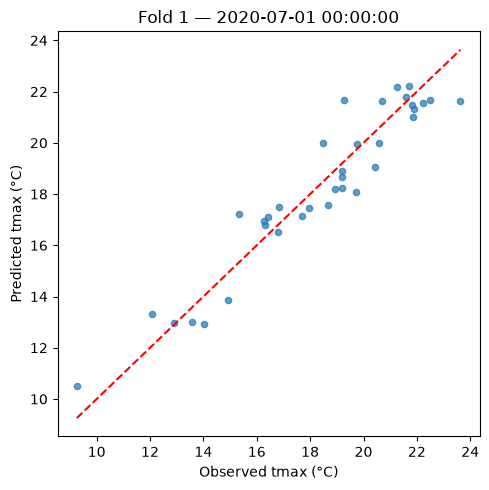

  Fold 1 done: 2557 days

Combined: 2557 days × 35 test stations


In [17]:
n_samples = T_common
combined_preds, combined_sigmas, combined_truths, combined_dates = [], [], [], []
combined_baselines = []

for fold in range(params.N_FOLDS):
    print(f"{'='*60}\nFold {fold+1}/{params.N_FOLDS}\n{'='*60}")

    checkpoint_path = MODEL_DIR / f'model_fold_{fold}'
    if not checkpoint_path.exists():
        print(f"  Checkpoint not found: {checkpoint_path}")
        continue

    model, epoch = model_factory.load_model_checkpoint(
        checkpoint_path, params, device, input_dim=6, context_input_dim=7, 
    )
    holdout_start, holdout_end = get_fold_holdout_indices(fold, params.N_FOLDS, n_samples)
    print(f"  Loaded epoch {epoch} | holdout {common_dates_pd[holdout_start]} → {common_dates_pd[holdout_end-1]}")

    fold_preds, fold_sigmas, fold_truths, fold_dates = [], [], [], []
    fold_baselines = []

    with torch.no_grad():
        for common_day_idx in range(holdout_start, holdout_end):
            date = common_dates_pd[common_day_idx]

            # CHANGED: ground truth from PW directly
            true_vals = y_true_all[common_day_idx]
            if np.all(np.isnan(true_vals)):
                continue


            xc = x_context[common_day_idx:common_day_idx+1].to(device)   # (1, 1872, 7)
            yc = y_context[common_day_idx:common_day_idx+1].to(device)   # (1, 1872, 1)
            xt = make_x_target_day(common_day_idx).unsqueeze(0)           # (1, n_test, 6)

            out = model(xc, yc, xt)                                        # (1, n_test, 2)
            mu_norm    = out[0, :, 0].cpu().numpy()
            sigma_norm = out[0, :, 1].cpu().numpy()

            preds_degC = metadata.denormalize(
                torch.tensor(mu_norm)
            ).numpy() - ds.KELVIN_OFFSET

            fold_preds.append(preds_degC)
            fold_sigmas.append(sigma_norm)
            fold_truths.append(true_vals)
            fold_dates.append(date)
            fold_baselines.append(all_baselines[common_day_idx])

    if not fold_preds:
        print(f"  No data — skipping")
        continue

    # Single-day scatter plot
    mid = len(fold_preds) // 2
    valid = ~np.isnan(fold_truths[mid])
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(fold_truths[mid][valid], fold_preds[mid][valid], alpha=0.7, s=20)
    lims = [min(fold_truths[mid][valid].min(), fold_preds[mid][valid].min()),
            max(fold_truths[mid][valid].max(), fold_preds[mid][valid].max())]
    ax.plot(lims, lims, 'r--')
    ax.set_xlabel('Observed tmax (°C)'); ax.set_ylabel('Predicted tmax (°C)')
    ax.set_title(f'Fold {fold+1} — {fold_dates[mid]}')
    plt.tight_layout(); plt.savefig(plot_path(f'fold{fold}_scatter')); plt.show()

    combined_preds.append(np.stack(fold_preds))
    combined_sigmas.append(np.stack(fold_sigmas))
    combined_truths.append(np.stack(fold_truths))
    combined_dates.extend(fold_dates)
    combined_baselines.append(np.stack(fold_baselines))
    print(f"  Fold {fold+1} done: {len(fold_preds)} days")

all_preds   = np.concatenate(combined_preds,  axis=0)
all_sigmas  = np.concatenate(combined_sigmas, axis=0)
all_truths  = np.concatenate(combined_truths, axis=0)
all_errors  = all_preds - all_truths
sigma_degC  = all_sigmas * metadata.data_std
all_baselines_holdout = np.concatenate(combined_baselines, axis=0)
total_days  = all_preds.shape[0]
print(f"\nCombined: {total_days} days × {all_preds.shape[1]} test stations")


## Combined Holdout Analysis (All Folds)

The following plots use the concatenated holdout predictions from all folds, covering the entire year.

Overall MAE:          1.051 °C
Overall RMSE:         1.362 °C
Overall Bias:         0.085 °C
Overall CRPS:         0.786 °C
Global skill score:   0.910


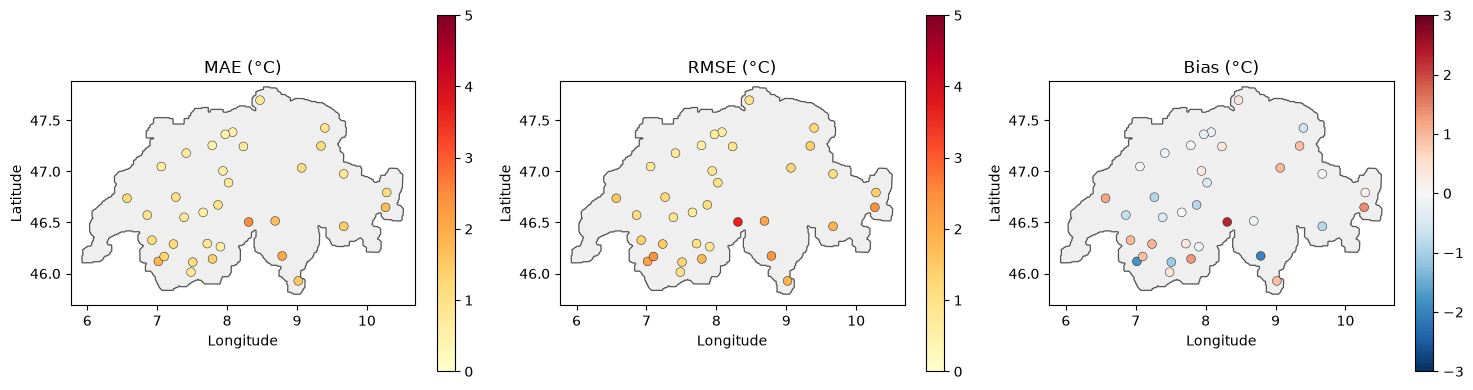

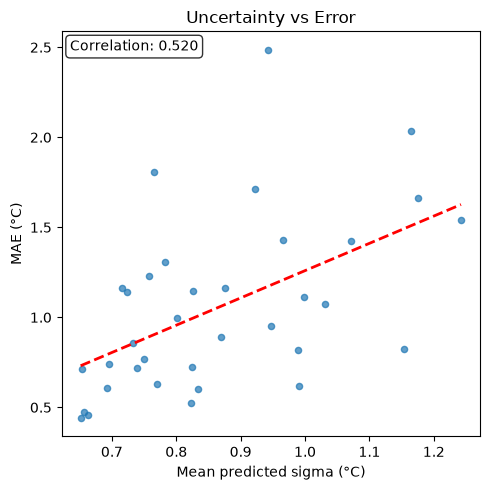

Per-station uncertainty-error correlation: 0.520


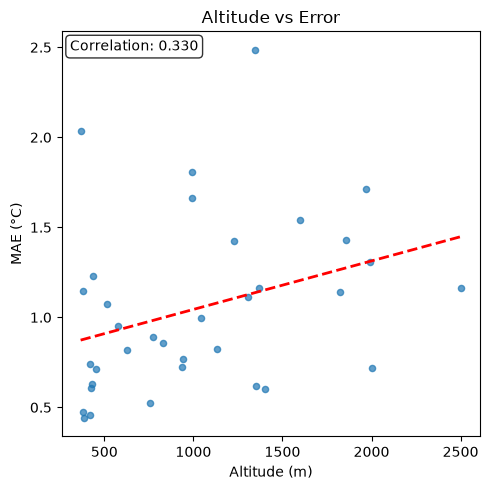

Altitude-error correlation: 0.330


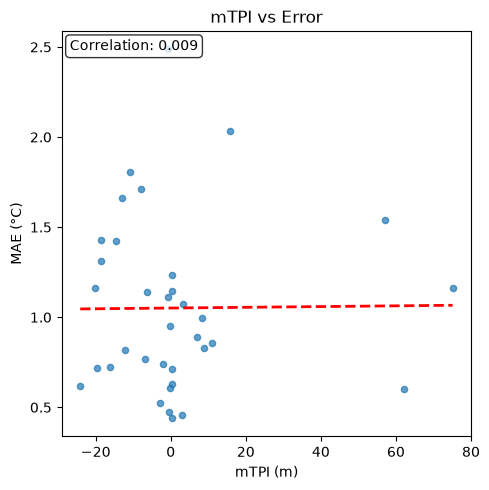

mTPI-error correlation: 0.009
  Saved plot: trained_models/test-combined-era5-pw-mean-13/plots/doy_vs_error.png


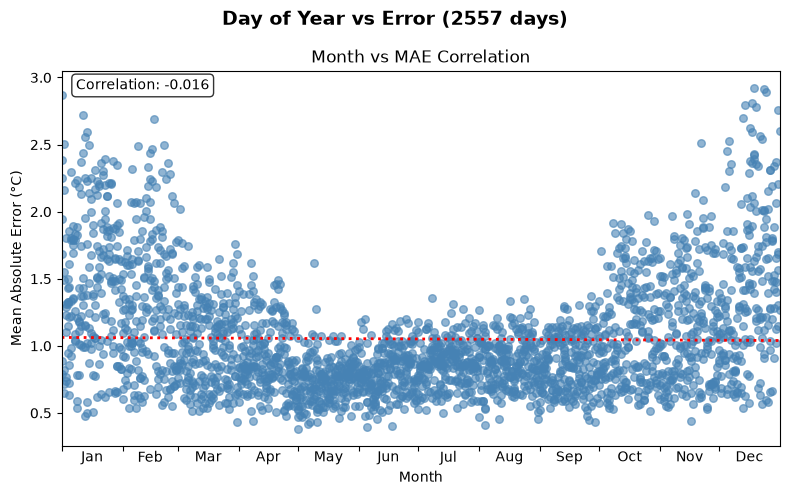

Day of year-error correlation: -0.016


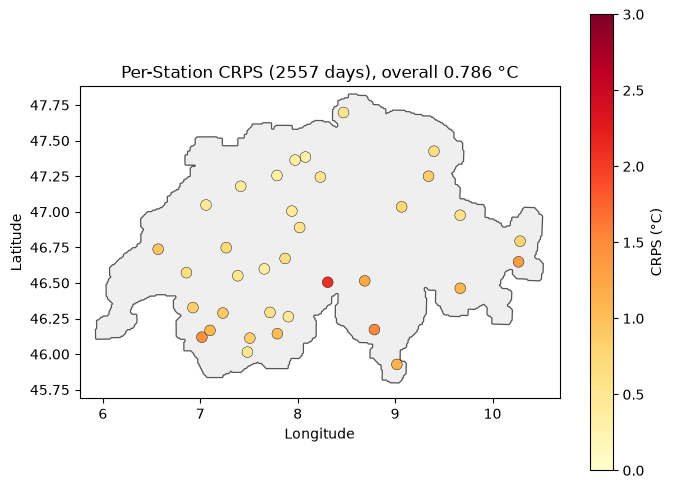

  Saved plot: trained_models/test-combined-era5-pw-mean-13/plots/skill_map.png


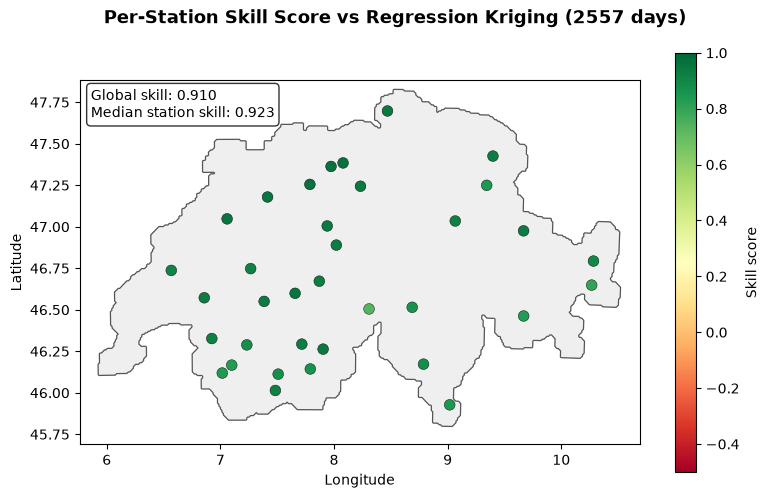

Saved station metrics to trained_models/test-combined-era5-pw-mean-13/station_metrics.npz


In [18]:
station_lats = stations_meta.loc[test_stations, 'latitude'].values
station_lons = stations_meta.loc[test_stations, 'longitude'].values
station_alts = stations_meta.loc[test_stations, 'station_height'].values
station_tpi = x_target_static[:, 3].cpu().numpy() * (2 * tpi_abs_max) - tpi_abs_max

m = metrics.compute_station_metrics(
    all_errors=all_errors,
    all_preds=all_preds,
    all_sigmas=sigma_degC,
    all_truths=all_truths,
    all_ref_preds=all_baselines_holdout,
)

mae_per_station   = m.mae
rmse_per_station  = m.rmse
bias_per_station  = m.bias
crps_per_station  = m.crps
sigma_per_station = m.mean_sigma

kriging_errors = all_baselines_holdout - all_truths   # already in °C
kriging_mae    = np.nanmean(np.abs(kriging_errors))
kriging_rmse   = np.sqrt(np.nanmean(kriging_errors**2))
kriging_bias   = np.nanmean(kriging_errors)

print(f"Overall MAE:          {np.nanmean(mae_per_station):.3f} °C")
print(f"Overall RMSE:         {np.nanmean(rmse_per_station):.3f} °C")
print(f"Overall Bias:         {np.nanmean(bias_per_station):.3f} °C")
print(f"Overall CRPS:         {m.overall_crps:.3f} °C")
print(f"Global skill score:   {m.global_skill:.3f}")

center_lat = (station_lats.min() + station_lats.max()) / 2
geo_aspect = 1.0 / np.cos(np.radians(center_lat))

# 1. Station error map
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, vals, title, cmap, vmin, vmax in zip(
    axes,
    [mae_per_station, rmse_per_station, bias_per_station],
    ['MAE (°C)', 'RMSE (°C)', 'Bias (°C)'],
    ['YlOrRd', 'YlOrRd', 'RdBu_r'],
    [0, 0, -3], [5, 5, 3],
):
    ax.contourf(border_lons_2d, border_lats_2d, border_valid_2d,
                levels=[0.5, 1.5], colors=['#cccccc'], alpha=0.3, zorder=1)
    ax.contour(border_lons_2d, border_lats_2d, border_valid_2d,
               levels=[0.5], colors='#555555', linewidths=0.9, zorder=2)
    sc = ax.scatter(station_lons, station_lats, c=vals, cmap=cmap,
                    vmin=vmin, vmax=vmax, s=40, edgecolors='k', linewidths=0.3, zorder=3)
    plt.colorbar(sc, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect(geo_aspect)
    ax.set_facecolor('white')
plt.tight_layout()
plt.savefig(plot_path('error_maps'))
plt.show()


# 2. Uncertainty vs error (per station)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(sigma_per_station, mae_per_station, alpha=0.7, s=20)
ax.set_xlabel('Mean predicted sigma (°C)')
ax.set_ylabel('MAE (°C)')
corr = np.corrcoef(sigma_per_station, mae_per_station)[0, 1]
slope, intercept = np.polyfit(sigma_per_station, mae_per_station, 1)
x_line = np.linspace(sigma_per_station.min(), sigma_per_station.max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2)
ax.set_title('Uncertainty vs Error')
ax.text(0.02, 0.98, f'Correlation: {corr:.3f}', transform=ax.transAxes,
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig(plot_path('uncertainty_vs_error'))
plt.show()
print(f"Per-station uncertainty-error correlation: {corr:.3f}")


# 3. Altitude vs error
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(station_alts, mae_per_station, alpha=0.7, s=20)
ax.set_xlabel('Altitude (m)')
ax.set_ylabel('MAE (°C)')
corr_alt = np.corrcoef(station_alts, mae_per_station)[0, 1]
slope, intercept = np.polyfit(station_alts, mae_per_station, 1)
x_line = np.linspace(station_alts.min(), station_alts.max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2)
ax.set_title('Altitude vs Error')
ax.text(0.02, 0.98, f'Correlation: {corr_alt:.3f}', transform=ax.transAxes,
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig(plot_path('altitude_vs_error'))
plt.show()
print(f"Altitude-error correlation: {corr_alt:.3f}")


# 4. mTPI vs error
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(station_tpi, mae_per_station, alpha=0.7, s=20)
ax.set_xlabel('mTPI (m)')
ax.set_ylabel('MAE (°C)')
corr_tpi = np.corrcoef(station_tpi, mae_per_station)[0, 1]
slope, intercept = np.polyfit(station_tpi, mae_per_station, 1)
x_line = np.linspace(station_tpi.min(), station_tpi.max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', linewidth=2)
ax.set_title('mTPI vs Error')
ax.text(0.02, 0.98, f'Correlation: {corr_tpi:.3f}', transform=ax.transAxes,
        verticalalignment='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig(plot_path('mtpi_vs_error'))
plt.show()
print(f"mTPI-error correlation: {corr_tpi:.3f}")


# 5. Day of year vs error (reuses existing visualization function)
all_holdout_dates = np.array(combined_dates, dtype='datetime64')
fig_doy, doy_corr = vis.plot_temporal_error_analysis(
    all_errors=all_errors,
    holdout_dates=all_holdout_dates,
    title=f'Day of Year vs Error ({total_days} days)',
    save_path=plot_path('doy_vs_error'),
)
plt.show()
print(f"Day of year-error correlation: {doy_corr:.3f}")

# 6. CRPS station map
fig, ax = plt.subplots(figsize=(7, 5))
ax.contourf(border_lons_2d, border_lats_2d, border_valid_2d,
            levels=[0.5, 1.5], colors=['#cccccc'], alpha=0.3, zorder=1)
ax.contour(border_lons_2d, border_lats_2d, border_valid_2d,
           levels=[0.5], colors='#555555', linewidths=0.9, zorder=2)
sc = ax.scatter(station_lons, station_lats, c=crps_per_station,
                cmap='YlOrRd', vmin=0, vmax=3, s=60,
                edgecolors='k', linewidths=0.3, zorder=3)
plt.colorbar(sc, ax=ax, label='CRPS (°C)')
ax.set_title(f'Per-Station CRPS ({total_days} days), '
             f'overall {np.nanmean(crps_per_station):.3f} °C')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect(geo_aspect)
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig(plot_path('crps_map'))
plt.show()


# 7. Skill score map
fig_skill = vis.plot_station_skill_map(
    skill_per_station=m.skill,
    station_lats=station_lats,
    station_lons=station_lons,
    global_skill=m.global_skill,
    title=f'Per-Station Skill Score vs Regression Kriging ({total_days} days)',
    swiss_border_lons_2d=border_lons_2d,
    swiss_border_lats_2d=border_lats_2d,
    swiss_border_valid=border_valid_2d,
    save_path=plot_path('skill_map'),
)

plt.show()

station_metrics_path = MODEL_DIR / 'station_metrics.npz'
np.savez(
    station_metrics_path,
    mae=mae_per_station,
    rmse=rmse_per_station,
    bias=bias_per_station,
    crps=crps_per_station,
    lats=station_lats,
    lons=station_lons,
    stations=np.array(test_stations),
)
print(f"Saved station metrics to {station_metrics_path}")

  Saved plot: trained_models/test-combined-era5-pw-mean-13/plots/qq_calibration.png


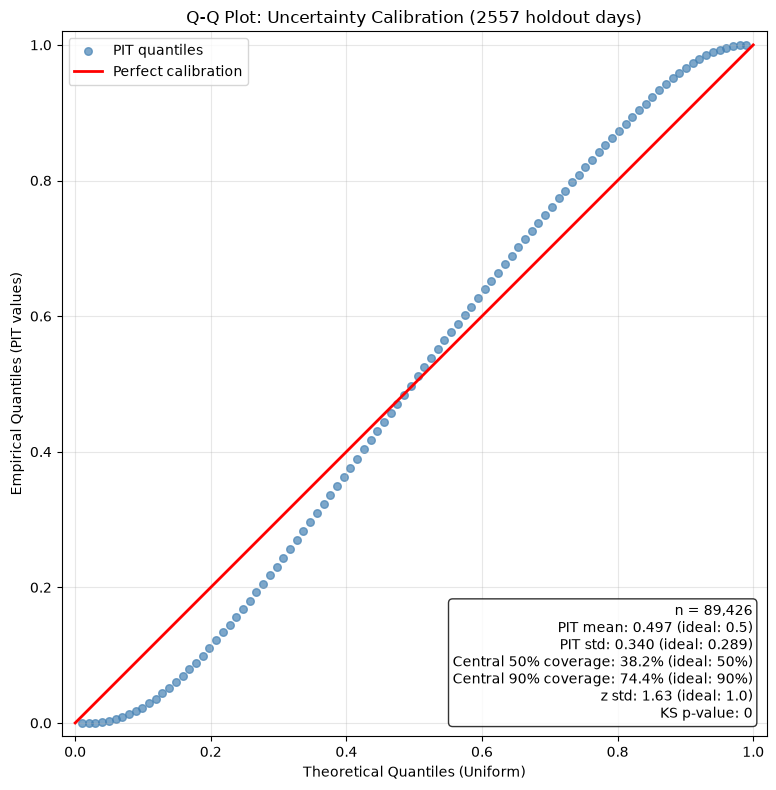


Calibration statistics:
  PIT mean: 0.497 (ideal: 0.5)
  PIT std:  0.340 (ideal: 0.289)
  z std:    1.63 (ideal: 1.0)
  50% coverage: 38.2% (ideal: 50%)
  90% coverage: 74.4% (ideal: 90%)
  KS test p-value: 0


In [19]:
from importlib import reload
vis = reload(vis)
# 8. Q-Q plot for uncertainty calibration
# Assesses whether the model's predicted uncertainty (sigma) is correctly calibrated.
# For a well-calibrated Gaussian model, PIT values (CDF of truth under predicted distribution)
# should follow Uniform(0, 1).
fig_qq, calibration_stats = vis.plot_qq_calibration(
    all_truths=all_truths,
    all_preds=all_preds,
    all_sigmas=sigma_degC,
    title=f"Q-Q Plot: Uncertainty Calibration ({total_days} holdout days)",
    save_path=plot_path("qq_calibration"),
)
plt.show()

print("\nCalibration statistics:")
print(f"  PIT mean: {calibration_stats['pit_mean']:.3f} (ideal: 0.5)")
print(f"  PIT std:  {calibration_stats['pit_std']:.3f} (ideal: 0.289)")
print(f"  z std:    {calibration_stats['z_std']:.2f} (ideal: 1.0)")
print(f"  50% coverage: {calibration_stats['coverage_50']:.1%} (ideal: 50%)")
print(f"  90% coverage: {calibration_stats['coverage_90']:.1%} (ideal: 90%)")
print(f"  KS test p-value: {calibration_stats['ks_p']:.3g}")

  Saved plot: trained_models/test-combined-era5-pw-mean-13/plots/reliability_diagram.png


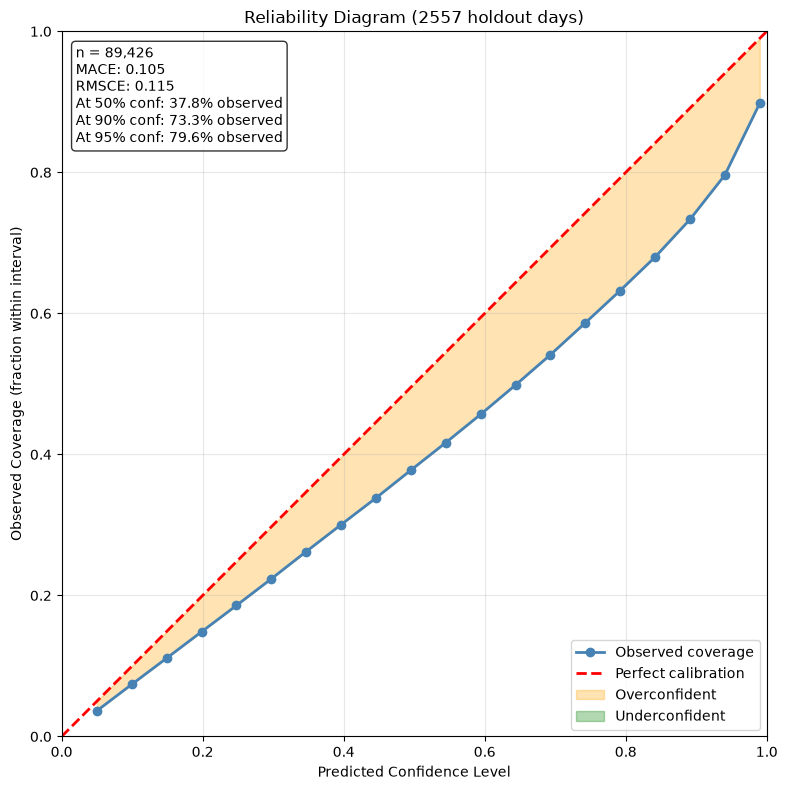


Reliability statistics:
  Mean Absolute Calibration Error (MACE): 0.105
  At 50% confidence: 37.8% observed (ideal: 50%)
  At 90% confidence: 73.3% observed (ideal: 90%)
  At 95% confidence: 79.6% observed (ideal: 95%)


In [20]:
# 9. Reliability diagram for uncertainty calibration
# Shows predicted confidence level vs observed coverage.
# If well-calibrated, the curve should follow the diagonal.
fig_reliability, reliability_stats = vis.plot_reliability_diagram(
    all_truths=all_truths,
    all_preds=all_preds,
    all_sigmas=sigma_degC,
    title=f"Reliability Diagram ({total_days} holdout days)",
    save_path=plot_path("reliability_diagram"),
)
plt.show()

print("\nReliability statistics:")
print(f"  Mean Absolute Calibration Error (MACE): {reliability_stats['mace']:.3f}")
print(f"  At 50% confidence: {reliability_stats['coverage_at_50']:.1%} observed (ideal: 50%)")
print(f"  At 90% confidence: {reliability_stats['coverage_at_90']:.1%} observed (ideal: 90%)")
print(f"  At 95% confidence: {reliability_stats['coverage_at_95']:.1%} observed (ideal: 95%)")

In [21]:
import json

metrics_path = MODEL_DIR / 'metrics.json'

metrics_dict = {
    "config": {
        "model_name": MODEL_NAME,
        "inference_dataset": "peakweather_test_stations",
        "context": "combined_era5_and_pw_train_stations",
        "n_context_stations": len(train_stations),
        "n_test_stations": len(test_stations),
        "station_split_seed": STATION_SPLIT_SEED,
        "n_folds": params.N_FOLDS,
        "holdout_days": int(total_days),
        "pw_first_date": PW_FIRST_DATE,
        "pw_last_date": PW_LAST_DATE,
        "pw_validity_threshold": PW_VALIDITY_THRESHOLD,
    },
    "overall": {
        "mae":  float(np.nanmean(mae_per_station)),
        "rmse": float(np.nanmean(rmse_per_station)),
        "bias": float(np.nanmean(bias_per_station)),
        "crps": float(np.nanmean(crps_per_station)),
        "skill_score": float(m.global_skill),
    },
    "correlations": {
        "uncertainty_error": float(corr),
        "altitude_error":    float(corr_alt),
        "mtpi_error":        float(corr_tpi),
        "doy_error":         float(doy_corr),
    },
    "calibration": {
        "pit_mean":    float(calibration_stats["pit_mean"]),
        "pit_std":     float(calibration_stats["pit_std"]),
        "z_std":       float(calibration_stats["z_std"]),
        "coverage_50": float(calibration_stats["coverage_50"]),
        "coverage_90": float(calibration_stats["coverage_90"]),
        "ks_p_value":  float(calibration_stats["ks_p"]),
    },
    "reliability": {
        "mace":            float(reliability_stats["mace"]),
        "coverage_at_50":  float(reliability_stats["coverage_at_50"]),
        "coverage_at_90":  float(reliability_stats["coverage_at_90"]),
        "coverage_at_95":  float(reliability_stats["coverage_at_95"]),
    },
}
metrics_path.write_text(json.dumps(metrics_dict, indent=2))
print(f"Metrics saved to {metrics_path}")

Metrics saved to trained_models/test-combined-era5-pw-mean-13/metrics.json


In [22]:
# Per-station summary table: altitude, MAE, RMSE, Bias — sorted by MAE
station_table = pd.DataFrame(
    {
        'Name':         stations_meta.loc[test_stations, 'station_name'].values,
        'Latitude':     np.round(station_lats, 4),
        'Longitude':    np.round(station_lons, 4),
        'Altitude (m)': station_alts.astype(int),
        'MAE (°C)':     np.round(mae_per_station, 3),
        'RMSE (°C)':    np.round(rmse_per_station, 3),
        'Bias (°C)':    np.round(bias_per_station, 3),
    },
    index=test_stations,
).sort_values('MAE (°C)')


print(f"Per-station metrics for {len(test_stations)} test stations (sorted by MAE):\n")
display(station_table)

Per-station metrics for 35 test stations (sorted by MAE):



,Name,Latitude,Longitude,Altitude (m),MAE (°C),RMSE (°C),Bias (°C)
BUS,Buchs / Aarau,47.3844,8.0796,386,0.440,0.579,-0.226
WYN,Wynau,47.2550,7.7875,421,0.460,0.595,-0.000
GOE,Gösgen,47.3631,7.9737,380,0.473,0.617,-0.260
FRU,Frutigen,46.5990,7.6575,756,0.525,0.685,-0.067
NAP,Napf,47.0047,7.9401,1403,0.604,0.837,0.258
GRE,Grenchen,47.1791,7.4151,427,0.607,0.781,-0.184
VSVIS,Visperterminen,46.2629,7.9042,1352,0.618,0.799,-0.178
CRM,Cressier,47.0476,7.0591,430,0.631,0.800,-0.075
MOA,Mosen,47.2438,8.2328,453,0.711,0.911,0.324
VSARO,Arolla,46.0140,7.4839,2005,0.717,0.917,0.388


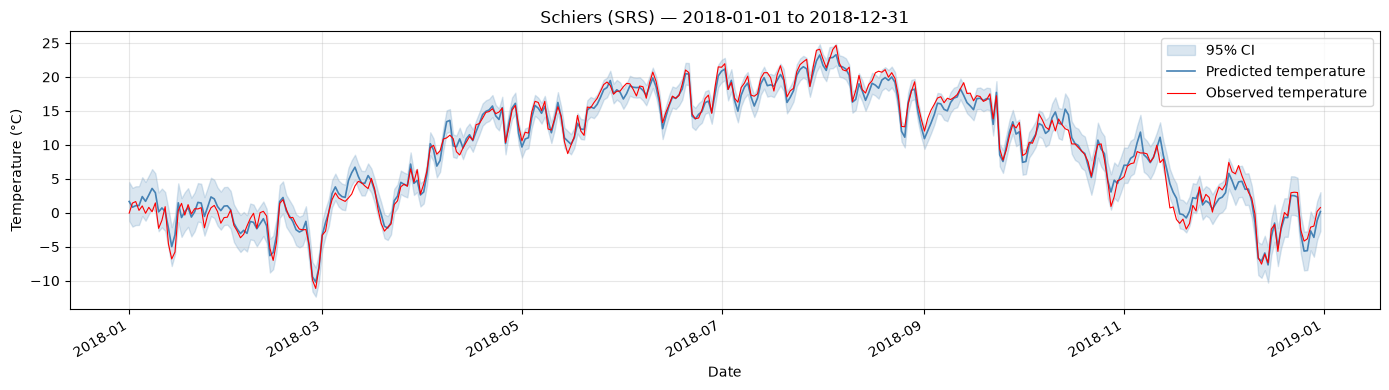

In [23]:
# ── Time-series plot: predicted vs observed for a single station ────────────
STATION_CODE  = 'SRS'
DATE_START    = '2018-01-01'
DATE_END      = '2018-12-31'

# Locate the station index among test stations
station_idx = list(test_stations).index(STATION_CODE)
station_name = stations_meta.loc[STATION_CODE, 'station_name']

# Filter to the requested date window (combined_dates may be non-contiguous across folds)
dates_arr = pd.DatetimeIndex(combined_dates)
mask = (dates_arr >= DATE_START) & (dates_arr <= DATE_END)
dates_plot  = dates_arr[mask]
preds_plot  = all_preds[mask, station_idx]
sigma_plot  = sigma_degC[mask, station_idx]
truths_plot = all_truths[mask, station_idx]

fig, ax = plt.subplots(figsize=(14, 4))

# Uncertainty band: mean ± 2σ
ax.fill_between(
    dates_plot,
    preds_plot - 2 * sigma_plot,
    preds_plot + 2 * sigma_plot,
    alpha=0.2, color='steelblue', label='95% CI',
)

# Predicted mean and observations
ax.plot(dates_plot, preds_plot, color='steelblue', linewidth=1.2, label='Predicted temperature')
ax.plot(dates_plot, truths_plot, color='red', linewidth=0.8, label='Observed temperature')


ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'{station_name} ({STATION_CODE}) — {DATE_START} to {DATE_END}')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


  Saved plot: trained_models/test-combined-era5-pw-mean-13/plots/predicted_vs_observed.png


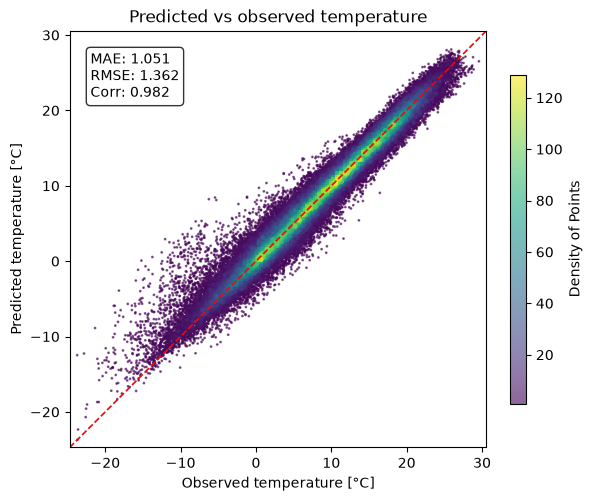

In [24]:
fig = vis.plot_predicted_vs_observed(
    all_preds=all_preds,
    all_truths=all_truths,
    title='Predicted vs observed temperature',
    save_path=plot_path('predicted_vs_observed'),
)

In [25]:
import pandas as pd

MAE_THRESHOLD = 2.5

# ── Table 1: every (day, station) pair with |error| > threshold ───────────────
rows = []
for d_idx, date in enumerate(combined_dates):
    month = pd.Timestamp(date).strftime('%B')
    for s_idx, station in enumerate(test_stations):
        abs_err = abs(all_errors[d_idx, s_idx])
        if np.isnan(abs_err) or abs_err <= MAE_THRESHOLD:
            continue
        rows.append({
            'Station':          station,
            'Name':             stations_meta.loc[station, 'station_name'],
            'Month':            month,
            'Abs. Error (°C)':  round(float(abs_err), 2),
        })

high_error_df = (
    pd.DataFrame(rows)
    .sort_values('Abs. Error (°C)', ascending=False)
    .reset_index(drop=True)
)
print(f"Individual predictions with |error| > {MAE_THRESHOLD}°C: {len(high_error_df)}")
display(high_error_df)

# ── Table 2: count per station ─────────────────────────────────────────────────
station_count_df = (
    high_error_df.groupby(['Station', 'Name'])
    .size()
    .reset_index(name='Count')
    .sort_values('Count', ascending=False)
    .reset_index(drop=True)
)
print(f"\nStations ranked by number of days with |error| > {MAE_THRESHOLD}°C:")
display(station_count_df)

# ── Table 2: count per station and month ──────────────────────────────────────
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

station_month_df = (
    high_error_df.groupby(['Station', 'Name', 'Month'])
    .size()
    .reset_index(name='Count')
)
station_month_df['Month'] = pd.Categorical(
    station_month_df['Month'], categories=month_order, ordered=True
)
station_month_df = (
    station_month_df
    .sort_values(['Count', 'Month'], ascending=[False, True])
    .reset_index(drop=True)
)
print(f"\nStations × months with |error| > {MAE_THRESHOLD}°C:")
display(station_month_df)



Individual predictions with |error| > 2.5°C: 7104


,Station,Name,Month,Abs. Error (°C)
0,VSSOR,Sorniot / Lac Inférieur,December,15.27
1,ULR,Ulrichen,January,14.97
2,VSSOR,Sorniot / Lac Inférieur,December,14.49
3,ULR,Ulrichen,January,14.48
4,ULR,Ulrichen,December,14.29
...,...,...,...,...
7099,BIV,Bivio,June,2.50
7100,VSMAT,Mattsand,November,2.50
7101,OTL,Locarno / Monti,September,2.50
7102,GEN,Monte Generoso,April,2.50



Stations ranked by number of days with |error| > 2.5°C:


,Station,Name,Count
0,ULR,Ulrichen,882
1,OTL,Locarno / Monti,779
2,MAR,Les Marécottes,675
3,BUF,Buffalora,584
4,PIO,Piotta,569
5,GEN,Monte Generoso,425
6,BIV,Bivio,408
7,VSMAT,Mattsand,387
8,VSSOR,Sorniot / Lac Inférieur,313
9,MAH,Mathod,257



Stations × months with |error| > 2.5°C:


,Station,Name,Month,Count
0,ULR,Ulrichen,January,169
1,ULR,Ulrichen,December,157
2,ULR,Ulrichen,February,136
3,BUF,Buffalora,December,132
4,OTL,Locarno / Monti,January,126
...,...,...,...,...
301,VSERG,Ergisch,October,1
302,FRU,Frutigen,November,1
303,CRM,Cressier,December,1
304,MOA,Mosen,December,1


In [26]:
# Load one fold's model without running the full prediction loop
grid_shape = (240, 370)

fold = 0   # any fold works for attention visualization
checkpoint_path = MODEL_DIR / f'model_fold_{fold}'
model, epoch = model_factory.load_model_checkpoint(
    checkpoint_path, params, device, input_dim=6, context_input_dim=7
)
print(f"Loaded model from fold {fold}, epoch {epoch}")

Built SMACNP with 3,179,459 trainable parameters
Loaded model from fold 0, epoch 94


In [27]:

from importlib import reload
import visualization as vis
vis = reload(vis)
from visualization import get_lat_lon_arrays, find_target_point, plot_attention_maps

# Build LOCATIONS automatically from the test station metadata
LOCATIONS = {
    sid: (stations_meta.loc[sid, 'latitude'], stations_meta.loc[sid, 'longitude'])
    for sid in test_stations
}

context_lats, context_lons, target_lats, target_lons = vis.get_lat_lon_arrays(
    x_context, x_target_static, metadata
)

viz_lats_1d = np.linspace(metadata.lat_min, metadata.lat_max, 240)
viz_lons_1d = np.linspace(metadata.lon_min, metadata.lon_max, 370)

print("Available test stations:")
for sid in test_stations:
    row = stations_meta.loc[sid]
    print(f"  {sid:6s}  {row['station_name']:<35s}  ({row['latitude']:.3f}°N, {row['longitude']:.3f}°E)")


Available test stations:
  AIG     Aigle                                (46.327°N, 6.924°E)
  BIV     Bivio                                (46.462°N, 9.669°E)
  BUF     Buffalora                            (46.648°N, 10.267°E)
  BUS     Buchs / Aarau                        (47.384°N, 8.080°E)
  CRM     Cressier                             (47.048°N, 7.059°E)
  EVO     Evolène / Villa                      (46.112°N, 7.509°E)
  FLU     Flühli, LU                           (46.889°N, 8.020°E)
  FRU     Frutigen                             (46.599°N, 7.658°E)
  GEN     Monte Generoso                       (45.928°N, 9.018°E)
  GLA     Glarus                               (47.035°N, 9.067°E)
  GOE     Gösgen                               (47.363°N, 7.974°E)
  GRE     Grenchen                             (47.179°N, 7.415°E)
  HLL     Hallau                               (47.697°N, 8.470°E)
  INT     Interlaken                           (46.672°N, 7.870°E)
  MAH     Mathod                    

BUF: target_point_idx=2, matched (46.6484°N, 10.2672°E), 0.00 km away


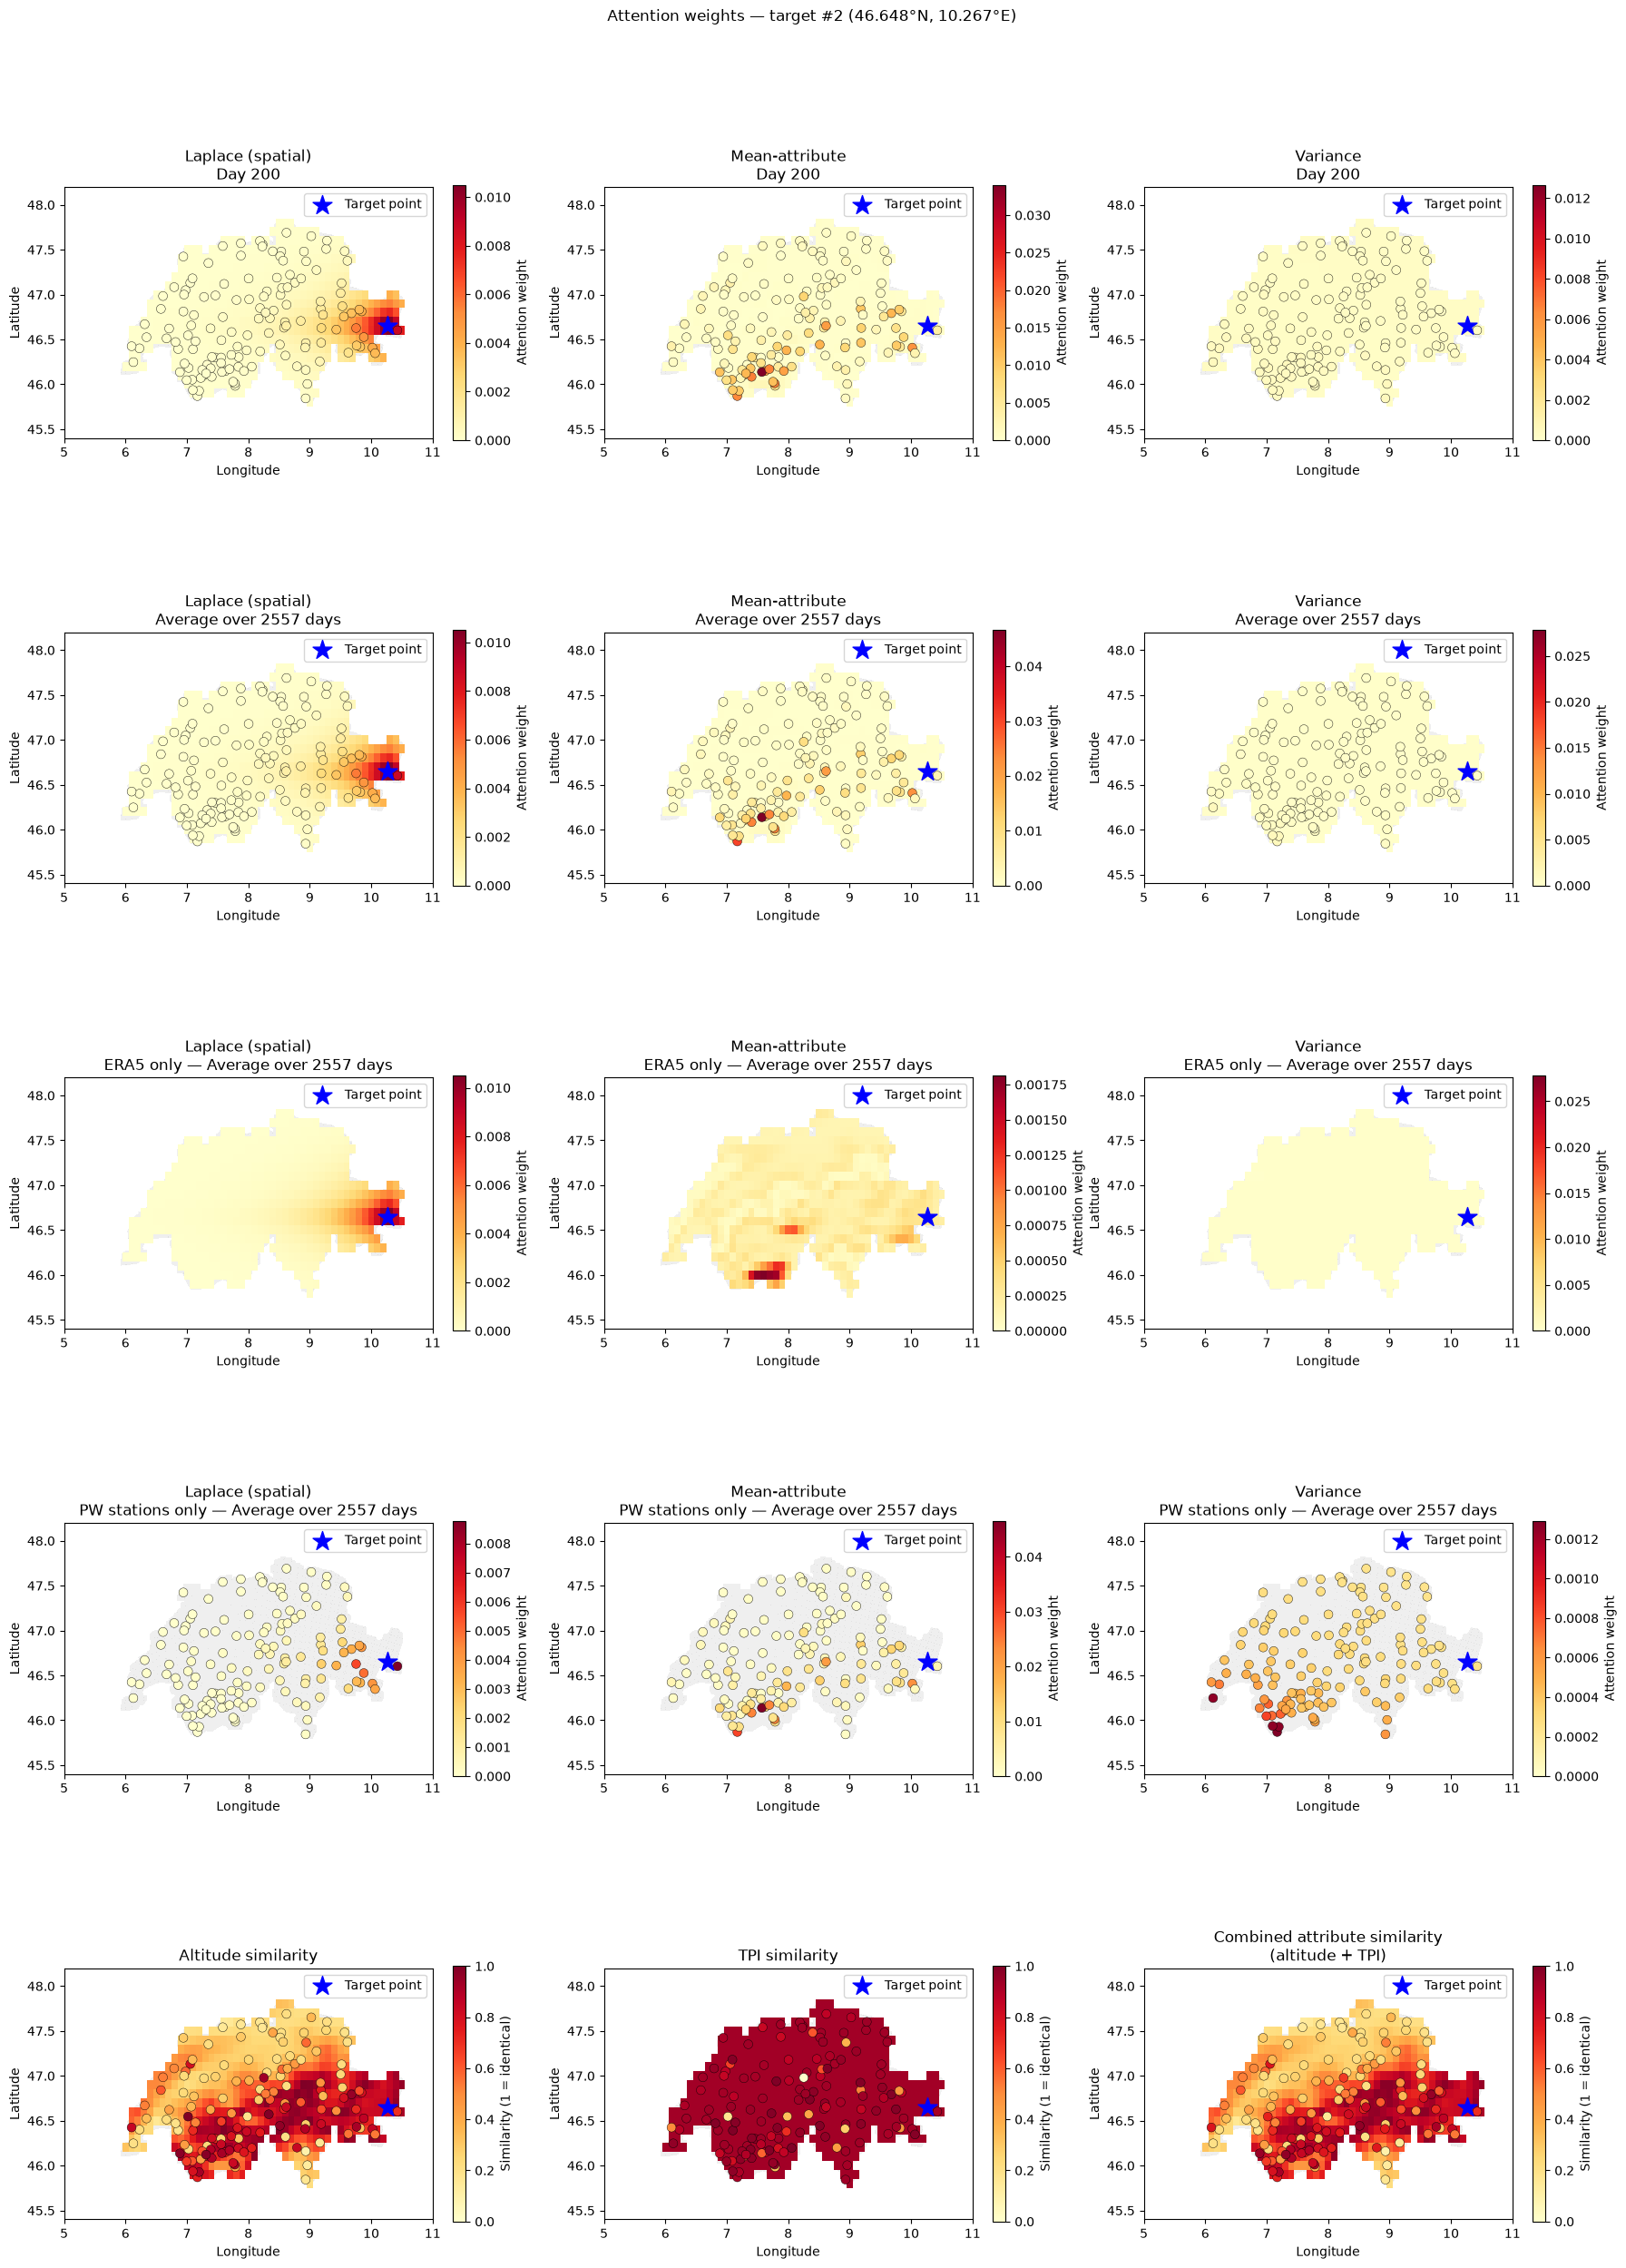

In [28]:
LOCATION        = 'BUF'   # station code from the list printed above
DAY_IDX         = 200
SHOW_AVERAGE    = True
SHOW_SIMILARITY = True
SHOW_SOURCE_SPLIT = True

lat, lon = LOCATIONS[LOCATION]
idx, matched_lat, matched_lon, dist_km = find_target_point(lat, lon, target_lats, target_lons)
print(f"{LOCATION}: target_point_idx={idx}, matched ({matched_lat:.4f}°N, {matched_lon:.4f}°E), {dist_km:.2f} km away")

fig = vis.plot_attention_maps(
    model=model, x_context=x_context, y_context=y_context,
    x_target_static=x_target_static, day_idx=DAY_IDX, target_point_idx=idx,
    grid_shape=grid_shape, metadata=metadata, device=device,
    y_target_flat=None,
    show_average=SHOW_AVERAGE,
    show_similarity=SHOW_SIMILARITY,
    show_source_split=SHOW_SOURCE_SPLIT,
    viz_grid_lats_1d=viz_lats_1d,
    viz_grid_lons_1d=viz_lons_1d,
    swiss_border_lons_2d=border_lons_2d,
    swiss_border_lats_2d=border_lats_2d,
    swiss_valid_2d=border_valid_2d,
)


Target: idx=2, matched (46.6484°N, 10.2672°E), 0.00 km away


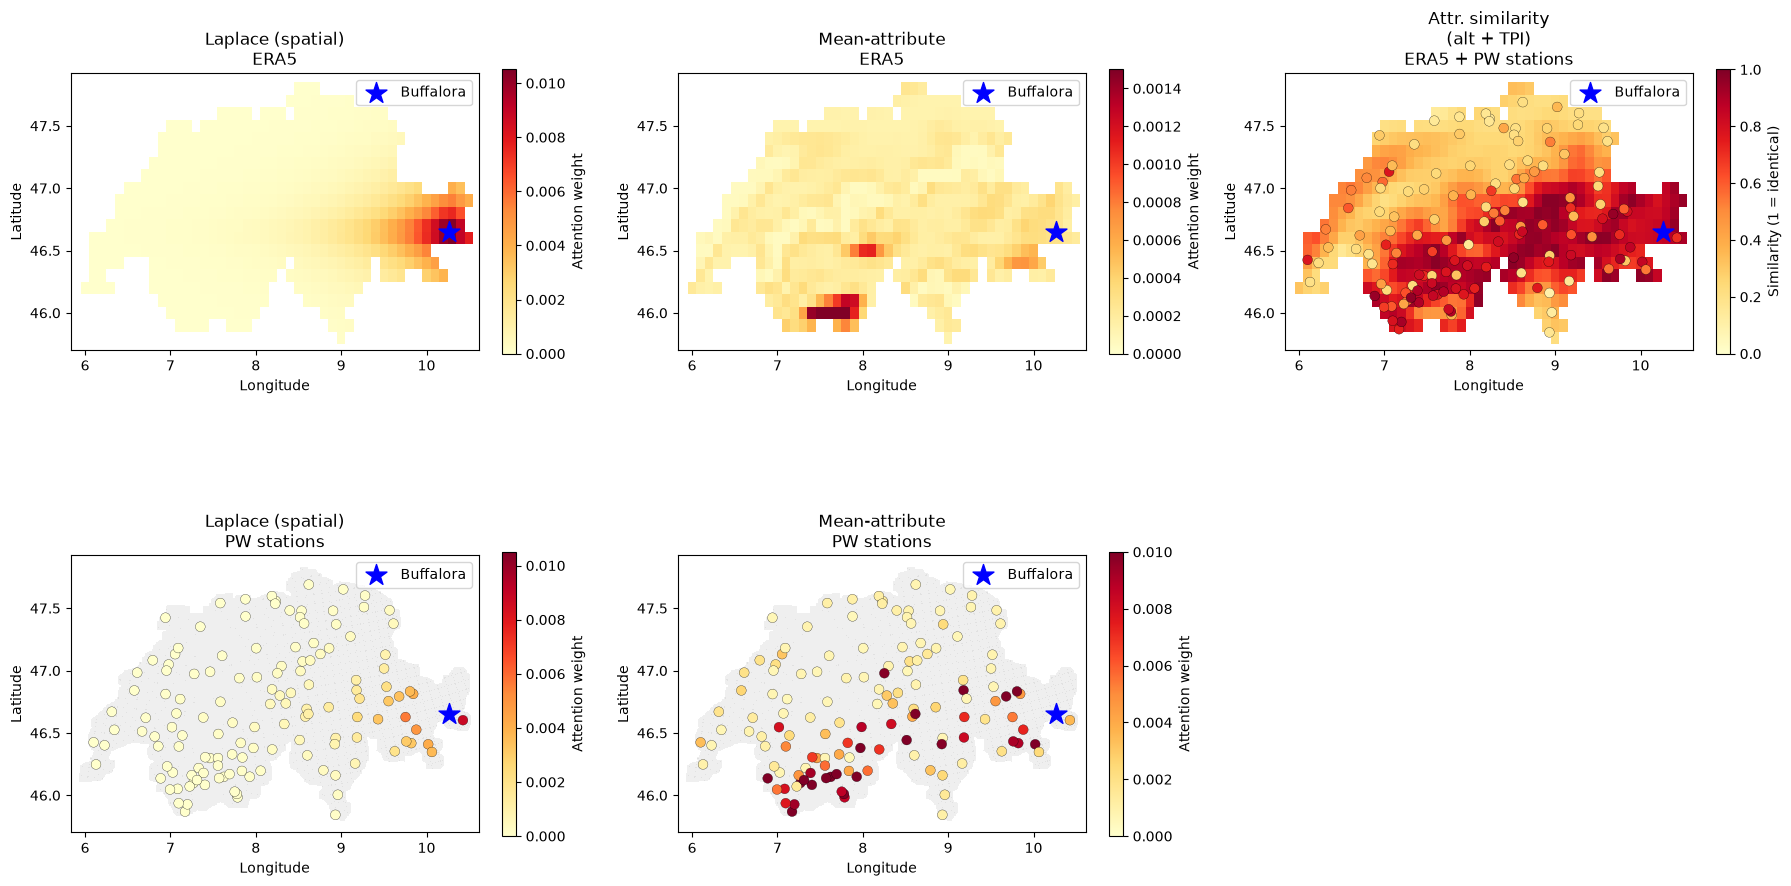

In [29]:




# ── Custom 2×3 attention map: ERA5 / PW rows, averaged over all days ──────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

ERA5_VMAX_OVERRIDE = {
    1: 0.002,   # mean-attribute column — set to None to use automatic
}

# ── Target station selection ───────────────────────────────────────────────────
# Option A — by name (uses LOCATIONS dict from the cell above)
LOCATION = 'BUF'   # change to any key in LOCATIONS
lat, lon = LOCATIONS[LOCATION]
#idx, matched_lat, matched_lon, dist_km = find_target_point(lat, lon, tgt_lats_d, tgt_lons_d)

# Option B — by coordinates directly (comment out Option A and uncomment below)
# lat, lon = 46.020, 7.749

# ── 1. Denormalise coordinates ─────────────────────────────────────────────────
lat_range = metadata.lat_max - metadata.lat_min
lon_range = metadata.lon_max - metadata.lon_min

context_lats_d = x_context[0, :, 0].cpu().numpy() * lat_range + metadata.lat_min
context_lons_d = x_context[0, :, 1].cpu().numpy() * lon_range + metadata.lon_min
tgt_lats_d = x_target_static[:, 0].cpu().numpy() * lat_range + metadata.lat_min
tgt_lons_d = x_target_static[:, 1].cpu().numpy() * lon_range + metadata.lon_min

idx, matched_lat, matched_lon, dist_km = find_target_point(lat, lon, tgt_lats_d, tgt_lons_d)
print(f"Target: idx={idx}, matched ({matched_lat:.4f}°N, {matched_lon:.4f}°E), {dist_km:.2f} km away")
target_label = stations_meta.loc[LOCATION, 'station_name']

tgt_lat = tgt_lats_d[idx]
tgt_lon = tgt_lons_d[idx]

# ── 2. Average attention weights over all days ─────────────────────────────────
static_pt = x_target_static[idx:idx+1].to(device)
T = x_context.shape[0]
laplace_sum = np.zeros(x_context.shape[1])
mean_sum    = np.zeros(x_context.shape[1])

model.eval()
for d in range(T):
    xc_d = x_context[d:d+1].to(device)
    yc_d = y_context[d:d+1].to(device)
    seasonal_d = torch.tensor([[xc_d[0, 0, 4].item(), xc_d[0, 0, 5].item()]], device=device)
    xt_d = torch.cat([static_pt, seasonal_d], dim=-1).unsqueeze(0)
    with torch.no_grad():
        _ = model(xc_d, yc_d, xt_d)
    laplace_sum += model.mean_loc_encoder.laplace_attention.last_weights[0, 0].cpu().numpy()
    mean_sum    += model.mean_attr_encoder.cross_attention.last_weights[0, 0].cpu().numpy()

laplace_w = laplace_sum / T
mean_w    = mean_sum    / T

# ── 3. ERA5 / PW masks from source flag (column 6: 0=ERA5, 1=PW) ──────────────
source_flag = x_context[0, :, -1].cpu().numpy()
era5_mask   = source_flag < 0.5
pw_mask     = ~era5_mask

era5_lats = context_lats_d[era5_mask]
era5_lons = context_lons_d[era5_mask]
era5_lats_u = np.sort(np.unique(np.round(era5_lats, 6)))
era5_lons_u = np.sort(np.unique(np.round(era5_lons, 6)))

# ── 4. Helper: flat ERA5 weights → 2-D grid masked to Switzerland ─────────────
def _to_era5_grid(w_flat):
    grid = np.full((len(era5_lats_u), len(era5_lons_u)), np.nan)
    for lat_k, lon_k, wk in zip(era5_lats, era5_lons, w_flat):
        i = np.searchsorted(era5_lats_u, round(lat_k, 6))
        j = np.searchsorted(era5_lons_u, round(lon_k, 6))
        if 0 <= i < len(era5_lats_u) and 0 <= j < len(era5_lons_u):
            grid[i, j] = wk
    era5_lat_2d, era5_lon_2d = np.meshgrid(era5_lats_u, era5_lons_u, indexing='ij')
    inside = griddata(
        np.column_stack([border_lats_2d.ravel(), border_lons_2d.ravel()]),
        border_valid_2d.ravel().astype(float),
        np.column_stack([era5_lat_2d.ravel(), era5_lon_2d.ravel()]),
        method='nearest', fill_value=0.0,
    ).reshape(era5_lat_2d.shape)
    return np.where(inside > 0.5, grid, np.nan)

# ── 5. Combined attribute similarity over ALL context points (shared scale) ────
tgt_alt  = x_target_static[idx, 2].item()
tgt_mTPI = x_target_static[idx, 3].item()
alt_d_all  = np.abs(x_context[0, :, 2].cpu().numpy() - tgt_alt)
tpi_d_all  = np.abs(x_context[0, :, 3].cpu().numpy() - tgt_mTPI)
comb_d_all = np.sqrt(alt_d_all**2 + tpi_d_all**2)
comb_sim_all = 1 - comb_d_all / (comb_d_all.max() + 1e-8)

# ── 6. Plot limits and aspect ratio ───────────────────────────────────────────
_valid_lons = border_lons_2d[border_valid_2d.astype(bool)]
_valid_lats = border_lats_2d[border_valid_2d.astype(bool)]
_pad_lon = 0.1
_pad_lat = 0.1
mch_extent = [_valid_lons.min() - _pad_lon, _valid_lons.max() + _pad_lon,
              _valid_lats.min() - _pad_lat, _valid_lats.max() + _pad_lat]
center_lat  = (_valid_lats.min() + _valid_lats.max()) / 2
geo_aspect  = 1.0 / np.cos(np.radians(center_lat))

def _setup_ax(ax, title):
    ax.scatter([tgt_lon], [tgt_lat], marker='*', c='blue', s=250, zorder=5, label=target_label)
    ax.set_xlim(mch_extent[0], mch_extent[1])
    ax.set_ylim(mch_extent[2], mch_extent[3])
    ax.set_aspect(geo_aspect)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.5))
    ax.set_title(title)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_facecolor('white')
    ax.legend()

# ── 7. Build 2×3 figure ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

col_info = [
    ('Laplace (spatial)',            laplace_w),
    ('Mean-attribute',               mean_w),
    ('Attr. similarity\n(alt + TPI)', None),
]

for col, (col_title, w_all) in enumerate(col_info):
    for row in range(2):
        ax = axes[row, col]

        if col == 2:
            if row == 1:
                ax.set_visible(False)
                continue
            # ERA5 cells
            im = ax.pcolormesh(era5_lons_u, era5_lats_u,
                               _to_era5_grid(comb_sim_all[era5_mask]),
                               cmap='YlOrRd', vmin=0, vmax=1, shading='nearest', zorder=3)
            plt.colorbar(im, ax=ax, label='Similarity (1 = identical)',
                         shrink=0.6, fraction=0.05)
            # PW stations on top
            ax.scatter(context_lons_d[pw_mask], context_lats_d[pw_mask],
                       c=comb_sim_all[pw_mask], cmap='YlOrRd', vmin=0, vmax=1,
                       s=50, zorder=4, edgecolors='k', linewidths=0.2)
            _setup_ax(ax, f'{col_title}\nERA5 + PW stations')
            continue

        if row == 0:
            vmax =  float(w_all[era5_mask].max())
            if col ==1:
                 vmax = 0.0015
            
            im = ax.pcolormesh(era5_lons_u, era5_lats_u,
                               _to_era5_grid(w_all[era5_mask]),
                               cmap='YlOrRd', vmin=0, vmax=vmax,
                               shading='nearest', zorder=3)
            plt.colorbar(im, ax=ax, label='Attention weight',
                         shrink=0.6, fraction=0.05)
        else:
            vmax = float(w_all[era5_mask].max())
            if col ==1:
                 vmax = 0.01
            ax.pcolormesh(border_lons_2d, border_lats_2d, border_valid_2d,
                          cmap='Greys', vmin=0, vmax=2, alpha=0.15,
                          shading='auto', zorder=1)
            sc = ax.scatter(context_lons_d[pw_mask], context_lats_d[pw_mask],
                            c=w_all[pw_mask], cmap='YlOrRd', vmin=0, vmax=vmax,
                            s=50, zorder=4, edgecolors='k', linewidths=0.2)
            plt.colorbar(sc, ax=ax, label='Attention weight',
                         shrink=0.6, fraction=0.05)

        row_label = 'ERA5' if row == 0 else 'PW stations'
        _setup_ax(ax, f'{col_title}\n{row_label}')

#plt.suptitle(
#    f"Attention weights (avg over {T} days) — target #{idx} ({tgt_lat:.3f}°N, {tgt_lon:.3f}°E)",
#    y=1.02, fontsize=14,
#)
plt.tight_layout()
plt.show()



## Summary

This notebook demonstrates how to:
1. Load trained SMACNP models using saved configuration (one per fold)
2. Reconstruct the holdout time periods used during cross-validation
3. Build the combined ERA5 + PeakWeather train context for each holdout day
4. **Per-fold:** Generate predictions at the 35 held-out PeakWeather test stations
   and plot a scatter of observed vs predicted temperatures for a representative day
5. **Combined across all folds:** Since holdout periods are non-overlapping,
   predictions from all folds are concatenated to produce a unified evaluation:
   - Per-station error maps (MAE, RMSE, Bias)
   - Uncertainty calibration (predicted σ vs actual MAE per station)
   - Error correlations with altitude and mTPI
   - Temporal error patterns (day-of-year analysis)
   - CRPS (Continuous Ranked Probability Score) for probabilistic calibration
   - Skill score relative to regression kriging baseline
   - Q-Q plot using Probability Integral Transform (PIT)
   - Reliability diagram for confidence calibration

### Interpretation of correlation plots:
- **Uncertainty vs Error:** High correlation indicates good calibration — the model "knows where it doesn't know"
- **Altitude vs Error:** Positive correlation suggests the model struggles more at high elevations
- **mTPI vs Error:** Positive values = ridges, negative = valleys. Correlation reveals terrain-dependent biases
- **Day of Year vs Error:** Reveals seasonal performance variations across the holdout period

### Interpretation of calibration plots:

**Q-Q Plot (PIT-based):**
- Computes PIT = CDF(truth | μ, σ) for each prediction
- If well-calibrated, PIT values should be Uniform(0,1)
- Points on diagonal = well-calibrated
- S-curve below diagonal = overconfident (intervals too narrow)
- S-curve above diagonal = underconfident (intervals too wide)

**Reliability Diagram:**
- X-axis: Predicted confidence level (e.g., 50%, 90%, 95%)
- Y-axis: Observed frequency (fraction of truths actually in that interval)
- Diagonal = perfect calibration
- Curve below diagonal (orange region) = overconfident
- Curve above diagonal (green region) = underconfident
- MACE (Mean Absolute Calibration Error) summarises miscalibration
